In [36]:
import pytato as yt
import pandas as pd
import numpy as np
import logomaker
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [3]:
proteome_df = yt.Silico().import_fasta(source="https://ftp.uniprot.org/pub/databases/uniprot/current_release/knowledgebase/reference_proteomes/Eukaryota/UP000005640/UP000005640_9606.fasta.gz")

FASTA import complete!


# Trypsin Standard

In [5]:
results = []
silico = yt.Silico()  

for index, row in proteome_df.head(5).iterrows():
    peptides = silico.cleave_sequence(sequence=row['Peptide'], enzyme="trypsin")
    for peptide in peptides:
        results.append({
            'Gene': row['Gene'],
            'Peptide': peptide
        })

peptides_df = pd.DataFrame(results)


In [6]:
peptides_df

,Gene,Peptide
0,A0A0A0MT85,XCSFGQGTK
1,HV692,MDCTWR
2,HV692,ILLLVAAATGTHAEVQLVQSGAEVK
3,HV692,KPGATVK
4,HV692,VSGYTFTDYYMHWVQQAPGK
5,HV692,GLEWMGLVDPEDGETIYAEK
6,HV692,VTITADTSTDTAYMELSSLR
7,HV692,SEDTAVYYCAT
8,SCGR4,MGCCGCGSCGGCGGR
9,SCGR4,CGGGCGGGCSGGCGGGCGGGCGGGCGSCTTCR


In [5]:
peptide_counts = peptides_df.groupby('Gene').size()
print(peptide_counts)


Gene
A0A0A0MT85     1
A0A6Q8PGS0     7
DHR12         21
HV692          7
SCGR4          6
dtype: int64


In [6]:

specific_proteins = proteome_df[proteome_df['Gene'].isin(['PDK1',"UBE3B"])]


In [7]:
silico.missed = 1


In [9]:
peptide_properties_dic = silico.generate_samples(specific_proteins,enzyme="trypsin", target="Peptide", identifier="Gene", pH=7.4, min_charge=1.5)
peptides_df = pd.DataFrame(peptide_properties_dic)


Processing your order with trypsin-cut proteins.
Generated 42 peptides matching criteria.


In [10]:
peptides_df = peptides_df.sort_values(by='Mass', ascending=False)
peptides_df

,gene,peptide,Length,aa_comp,neutral_z,z,Mass,GRAVY,m/z
21,UBE3B,GLARPRPCLSKGTLTAAFSLALRPVIAAQFSDNLIRPFLIHIMSVP...,59,"{'N': 1, 'F': 3, 'G': 2, 'V': 4, 'K': 1, 'P': ...",4,4,6344.528628,0.503390,1586.132157
19,UBE3B,GESLRPAMNHICANIMGHLNQHGFYSVLQILLTRGLARPRPCLSK,45,"{'N': 3, 'F': 1, 'G': 4, 'V': 1, 'K': 1, 'P': ...",4,4,4994.588069,-0.044444,1248.647017
18,UBE3B,GKGESLRPAMNHICANIMGHLNQHGFYSVLQILLTR,36,"{'N': 3, 'F': 1, 'G': 4, 'V': 1, 'K': 1, 'P': ...",2,2,4001.033864,-0.025000,2000.516932
37,UBE3B,AMFLKFVTSCSRPPLLGFAYLKPPFSIR,28,"{'F': 4, 'V': 1, 'G': 1, 'K': 2, 'P': 4, 'A': ...",4,4,3167.718039,0.539286,791.929510
38,UBE3B,FVTSCSRPPLLGFAYLKPPFSIR,23,"{'F': 3, 'V': 1, 'G': 1, 'K': 1, 'P': 4, 'A': ...",3,3,2577.392999,0.378261,859.131000
35,UBE3B,NQTAALISGFRSIIKPEWIR,20,"{'W': 1, 'N': 1, 'F': 1, 'G': 1, 'K': 1, 'P': ...",2,2,2281.269521,-0.020000,1140.634760
10,PDK1,LFNYMYSTAPRPRVETSR,18,"{'N': 1, 'F': 1, 'V': 1, 'P': 2, 'A': 1, 'L': ...",2,2,2168.094911,-0.822222,1084.047456
33,UBE3B,ISYIHLMAHFRMHTQIK,17,"{'F': 1, 'K': 1, 'A': 1, 'L': 1, 'I': 3, 'Q': ...",2,2,2108.081184,0.082353,1054.040592
28,UBE3B,AQLILQYIPHVIPHKNR,17,"{'N': 1, 'V': 1, 'K': 1, 'P': 2, 'A': 1, 'I': ...",2,2,2023.136707,-0.158824,1011.568353
40,UBE3B,LPTSSTCFNLLKLPNYSK,18,"{'N': 2, 'F': 1, 'K': 2, 'P': 2, 'L': 4, 'S': ...",2,2,2007.049925,-0.144444,1003.524962


<Figure size 500x400 with 0 Axes>

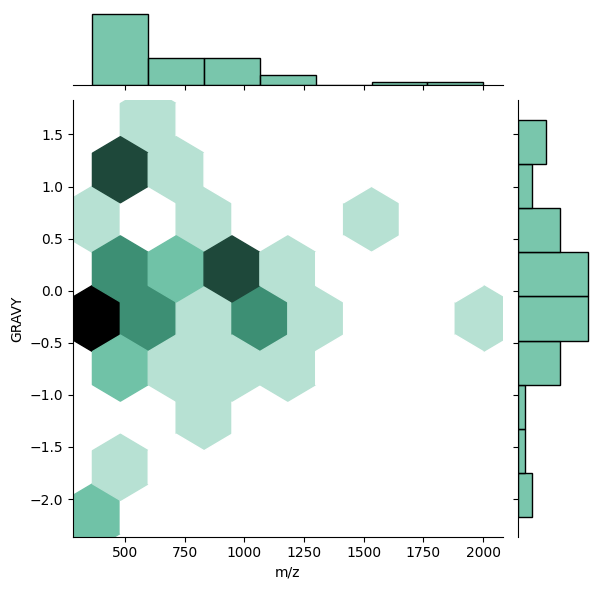

In [11]:

x = peptides_df['m/z']
y = peptides_df['GRAVY']


plt.figure(figsize=(5, 4))
sns.jointplot(x=x, y=y, kind="hex", color="#4CB391")


plt.show()

<Figure size 500x400 with 0 Axes>

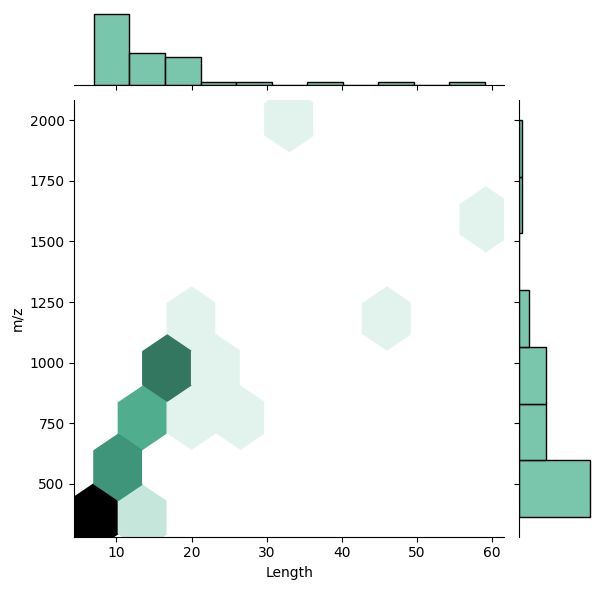

In [12]:
x = peptides_df['Length']
y = peptides_df['m/z']

plt.figure(figsize=(5, 4))
sns.jointplot(x=x, y=y, kind="hex", color="#4CB391")

plt.show()

In [13]:
peptide_counts = peptides_df.groupby('gene').size()
print(peptide_counts)



gene
PDK1     12
UBE3B    30
dtype: int64


# Testing Area for Adding New Enzyme (i.e CL3 Q-S/A/G)

In [136]:
import re

def test_cleavage(sequence):
    """
    Simulate cleavage of a protein sequence using custom enzyme rule.
    
    Parameters:
    - sequence (str): The protein sequence to be cleaved.
    
    Returns:
    - list[str]: A list of peptides resulting from the cleavage.
    """
    # q_sag cleavage rule: Cleave at Q when followed by S, A, or G
    test_rule = '(L|Q)(?=S|A|G)'
    
    # Find all cleavage sites
    cleavage_sites = [match.end() for match in re.finditer(test_rule, sequence)]
    
    # Simulate cleavage to generate peptides
    peptides = []
    start = 0
    for site in cleavage_sites:
        peptide = sequence[start:site]
        if peptide:
            peptides.append(peptide)
        start = site
    # Add the last peptide fragment, if any
    if start < len(sequence):
        peptides.append(sequence[start:])
    
    return peptides

# Example protein sequences
sequences = [
    "KTILDDWQLSKKKAAA",
    "MQQSQQSAG",
]

# Test the q_sag cleavage rule on each sequence
for seq in sequences:
    peptides = test_cleavage(seq)
    print(f"Original sequence: {seq}")
    print(f"Peptides after test cleavage: {peptides}\n")


Original sequence: KTILDDWQLSKKKAAA
Peptides after test cleavage: ['KTILDDWQL', 'SKKKAAA']

Original sequence: MQQSQQSAG
Peptides after test cleavage: ['MQQ', 'SQQ', 'SAG']



# Peptide Analysis for CL3 Enzyme

In [137]:
silico.rules['CL3'] = '(L|Q)(?=S|A|G)'

In [138]:
peptide_properties_df = silico.generate_samples(proteome_df, target="Peptide", identifier="Gene", enzyme="CL3")


Processing your order with CL3-cut proteins.
Generated 520966 peptides matching criteria.


In [139]:
peptides_df = pd.DataFrame(peptide_properties_df)
peptides_df = peptides_df.sort_values(by='z', ascending=True)
filtered_df = peptides_df[peptides_df['Length'] <= 40]
filtered_df['charge'] = filtered_df['z'].round(0)
filtered_df

C:\Users\tcoop\AppData\Local\Temp\ipykernel_20356\4252205849.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['charge'] = filtered_df['z'].round(0)


,gene,peptide,Length,aa_comp,neutral_z,z,Mass,GRAVY,m/z,charge
73437,TYRP2,SCLGCKILPGAQ,12,"{'G': 2, 'K': 1, 'P': 1, 'A': 1, 'L': 2, 'I': ...",1,2,1171.572952,0.691667,585.786476,2
293241,CHADL,GRLIYLYLSDNQL,13,"{'N': 1, 'G': 1, 'I': 1, 'L': 4, 'Q': 1, 'S': ...",0,2,1549.814026,0.069231,774.907013,2
293242,CHADL,AGLSAAALEGAPRL,14,"{'G': 2, 'P': 1, 'A': 5, 'L': 3, 'S': 1, 'R': ...",0,2,1276.725171,0.657143,638.362585,2
293243,CHADL,SAAALEGAPRL,11,"{'G': 1, 'P': 1, 'A': 4, 'L': 2, 'S': 1, 'R': ...",0,2,1035.582529,0.363636,517.791265,2
293250,CHADL,SGNRITEVSL,10,"{'N': 1, 'G': 1, 'V': 1, 'I': 1, 'L': 1, 'S': ...",0,2,1055.572357,-0.170000,527.786179,2
...,...,...,...,...,...,...,...,...,...,...
506218,HEXI1,GKKKHRRRPSKKKRHWKPYYKLTWEEKKKFDEKQ,34,"{'W': 2, 'F': 1, 'G': 1, 'K': 12, 'P': 2, 'L':...",12,19,4461.551537,-2.694118,234.818502,19
244647,LUC7L,SRRSGSRTRDRRRSRSRDRRRRRSRSTSRERRKL,34,"{'G': 1, 'K': 1, 'L': 1, 'S': 8, 'R': 18, 'T':...",16,20,4364.484535,-2.935294,218.224227,20
361976,KNG1,GGHVLDHGHKHKHGHGHGKHKNKGKKNGKHNGWKTEHL,38,"{'W': 1, 'N': 3, 'G': 9, 'V': 1, 'K': 9, 'L': ...",7,20,4234.214799,-2.052632,211.710740,20
228823,K2026,SHKKLKLTKMRAKKKKKKKKKLKDVLNENLQRKREGLHSL,40,"{'N': 2, 'V': 1, 'G': 1, 'K': 15, 'A': 1, 'L':...",15,21,4816.985808,-1.690000,229.380277,21


In [140]:
peptide_counts = peptides_df.groupby('gene').size()
print(peptide_counts)


gene
1433B     18
1433E     15
1433F     16
1433G     16
1433S     23
        ... 
ZY11A     37
ZY11B     32
ZYX       22
ZZEF1    156
ZZZ3      24
Length: 20465, dtype: int64


<Figure size 500x400 with 0 Axes>

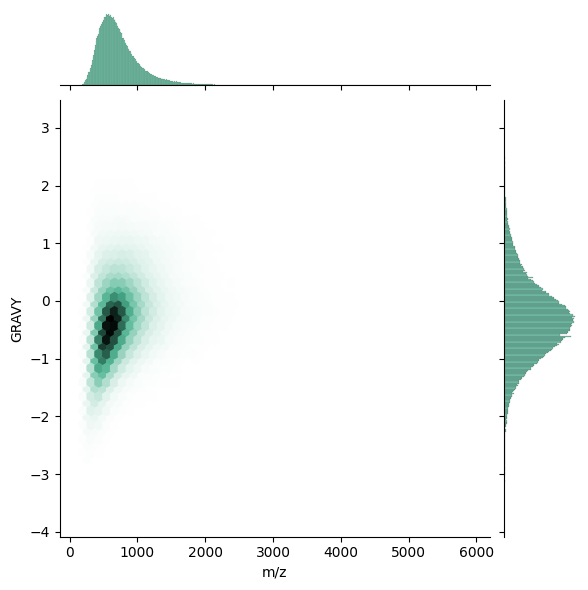

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns
x = peptides_df['m/z']
y = peptides_df['GRAVY']

# Plot the joint distribution using hexagonal bins
plt.figure(figsize=(5, 4))
sns.jointplot(x=x, y=y, kind="hex", color="#4CB391")

# Show the plot
plt.show()

<Figure size 500x400 with 0 Axes>

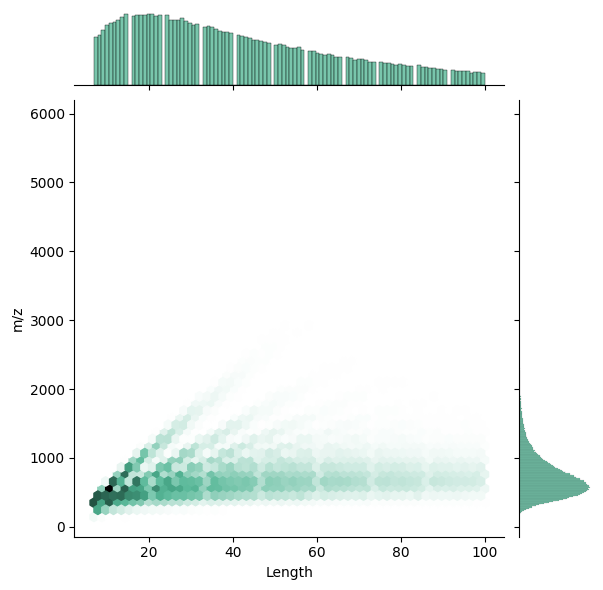

In [142]:
x = peptides_df['Length']
y = peptides_df['m/z']

# Plot the joint distribution using hexagonal bins
plt.figure(figsize=(5, 4))
sns.jointplot(x=x, y=y, kind="hex", color="#4CB391")

# Show the plot
plt.show()

# Papain

In [ ]:
# silico.rules['papain'] = '[KR](?=[LG])'

In [ ]:
# peptide_properties_df = silico.generate_samples(proteome_df, target="Peptide", identifier="Gene", enzyme="papain")


In [ ]:
# peptides_df = pd.DataFrame(peptide_properties_df)
# peptides_df

In [ ]:
# x = peptides_df['Length']
# y = peptides_df['m/z']

# # Plot the joint distribution using hexagonal bins
# plt.figure(figsize=(5, 4))
# sns.jointplot(x=x, y=y, kind="hex", color="#4CB391")

# # Show the plot
# plt.show()

In [ ]:
# x = peptides_df['Length']
# y = peptides_df['m/z']

# # Plot the joint distribution using hexagonal bins
# plt.figure(figsize=(5, 4))
# sns.jointplot(x=x, y=y, kind="hex", color="#4CB391")

# # Show the plot
# plt.show()

# Compare Two Enzymes

In [63]:
enzyme1="trypsin"
e1_label="Trypsin"
enzyme2="glutamyl endopeptidase"
e2_label="GluC"
enzymes=[enzyme1,enzyme2]
enzyme_color={e1_label:"green",e2_label:"purple"}
two_proteome= proteome_df[proteome_df['Gene'].isin(['CDK1',"UBE3B"])] # Mute line below if you wish to focus on list of Genes
# two_proteome=proteome_df
two_digest={}
for enzyme in enzymes:
    temp_list = silico.generate_samples(two_proteome, target="Peptide", identifier="Gene", enzyme=enzyme)
    temp_df = pd.DataFrame(temp_list)
    temp_df["enzyme"] = enzyme
    two_digest[enzyme]=temp_df
combined_df = pd.concat(two_digest.values(), ignore_index=True)
combined_df['enzyme'] = combined_df['enzyme'].replace(enzyme1, e1_label)
combined_df['enzyme'] = combined_df['enzyme'].replace(enzyme2, e2_label)
combined_df

Processing your order with trypsin-cut proteins.
Generated 75 peptides matching criteria.
Processing your order with glutamyl endopeptidase-cut proteins.
Generated 50 peptides matching criteria.


,gene,peptide,Length,aa_comp,neutral_z,z,Mass,GRAVY,m/z,enzyme
0,CDK1,IGEGTYGVVYK,11,"{'G': 3, 'V': 2, 'T': 1, 'E': 1, 'I': 1, 'Y': ...",0,2,1165.613144,0.090909,582.806572,Trypsin
1,CDK1,TTGQVVAMK,9,"{'V': 2, 'G': 1, 'T': 2, 'K': 1, 'Q': 1, 'A': ...",1,2,916.468805,0.322222,458.234402,Trypsin
2,CDK1,LESEEEGVPSTAIR,14,"{'G': 1, 'V': 1, 'T': 1, 'E': 4, 'I': 1, 'P': ...",-3,2,1493.795042,-0.607143,746.897521,Trypsin
3,CDK1,HPNIVSLQDVLMQDSR,16,"{'Q': 2, 'V': 2, 'I': 1, 'M': 1, 'D': 2, 'H': ...",-1,3,1834.888347,-0.375000,611.629449,Trypsin
4,CDK1,LYLIFEFLSMDLK,13,"{'E': 1, 'I': 1, 'M': 1, 'Y': 1, 'K': 1, 'D': ...",-1,2,1611.873465,1.092308,805.936732,Trypsin
...,...,...,...,...,...,...,...,...,...,...
120,UBE3B,DLKKHTVYYGGFHGSHRVIIWLWDILASDFTPDE,34,"{'V': 2, 'G': 3, 'T': 2, 'E': 1, 'I': 3, 'K': ...",-2,7,3996.011113,-0.261765,570.858730,GluC
121,UBE3B,RAMFLKFVTSCSRPPLLGFAYLKPPFSIRCVE,32,"{'V': 2, 'G': 1, 'T': 1, 'E': 1, 'I': 1, 'M': ...",4,6,3653.955327,0.431250,608.992554,GluC
122,UBE3B,VSDDQDTGDTLGSVLRGFFTIRKRE,25,"{'V': 2, 'G': 3, 'T': 3, 'E': 1, 'I': 1, 'K': ...",-1,5,2793.404572,-0.688000,558.680914,GluC
123,UBE3B,PGGRLPTSSTCFNLLKLPNYSKKSVLRE,28,"{'G': 2, 'V': 1, 'T': 2, 'E': 1, 'K': 3, 'Y': ...",4,6,3085.685886,-0.507143,514.280981,GluC


In [64]:
# Assuming 'enzyme' is the column indicating the enzyme used,
# and 'Gene' indicates the identified protein for each peptide
peptide_counts = combined_df.groupby('enzyme').size()
protein_counts = combined_df.groupby('enzyme')['gene'].nunique()

In [65]:
peptide_counts

enzyme
GluC       50
Trypsin    75
dtype: int64

In [66]:
protein_counts

enzyme
GluC       2
Trypsin    2
Name: gene, dtype: int64

In [67]:

# Create a DataFrame from the two Series for easier plotting
counts_df = pd.DataFrame({'Peptides': peptide_counts, 'Proteins': protein_counts}).reset_index()
colors = [enzyme_color[enzyme] for enzyme in counts_df['enzyme']]



In [68]:
peptide_data = counts_df[['enzyme', 'Peptides']]
protein_data = counts_df[['enzyme', 'Proteins']]

C:\Users\tcoop\AppData\Local\Temp\ipykernel_27528\3142940531.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_peptides.set_xticklabels(peptide_data['enzyme'], fontsize=16)
C:\Users\tcoop\AppData\Local\Temp\ipykernel_27528\3142940531.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_proteins.set_xticklabels(protein_data['enzyme'], fontsize=16)


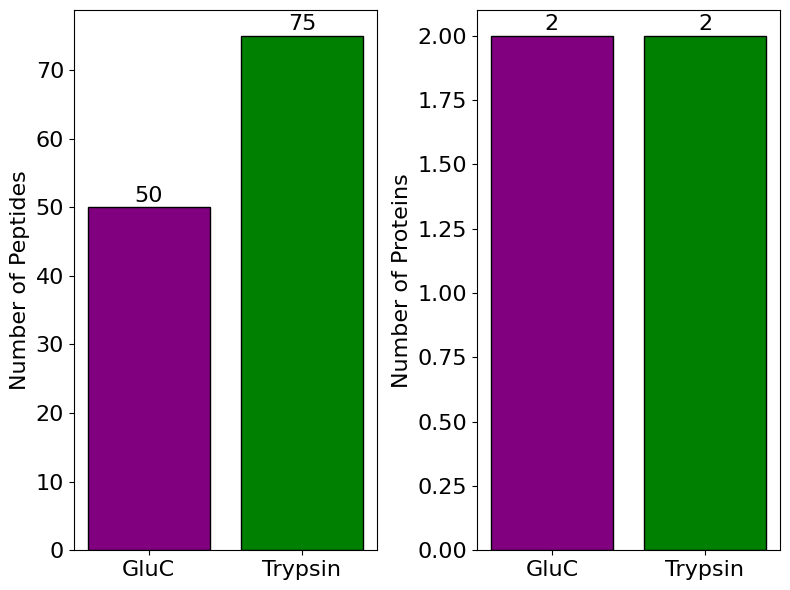

In [69]:
# Create subplots with 1 row and 2 columns
fig, (ax_peptides, ax_proteins) = plt.subplots(1, 2, figsize=(8, 6))

# Bar plot for peptides on the first subplot
peptide_bars = ax_peptides.bar(peptide_data['enzyme'], peptide_data['Peptides'], color=[enzyme_color[e] for e in peptide_data['enzyme']], edgecolor='black')
ax_peptides.set_ylabel('Number of Peptides', fontsize=16)
ax_peptides.set_xticklabels(peptide_data['enzyme'], fontsize=16)
ax_peptides.tick_params(axis='y', labelsize=16)

# Adding labels on top of peptide bars
for bar in peptide_bars:
    height = bar.get_height()
    ax_peptides.annotate('{}'.format(int(height)),
                         xy=(bar.get_x() + bar.get_width() / 2, height),
                         xytext=(0, 1),  # 3 points vertical offset
                         textcoords="offset points",
                         ha='center', va='bottom', fontsize=16)

# Bar plot for proteins on the second subplot
protein_bars = ax_proteins.bar(protein_data['enzyme'], protein_data['Proteins'], color=[enzyme_color[e] for e in protein_data['enzyme']], edgecolor='black')
ax_proteins.set_ylabel('Number of Proteins', fontsize=16)
ax_proteins.set_xticklabels(protein_data['enzyme'], fontsize=16)
ax_proteins.tick_params(axis='y', labelsize=16)

# Adding labels on top of protein bars
for bar in protein_bars:
    height = bar.get_height()
    ax_proteins.annotate('{}'.format(int(height)),
                         xy=(bar.get_x() + bar.get_width() / 2, height),
                         xytext=(0, 1),  # 3 points vertical offset
                         textcoords="offset points",
                         ha='center', va='bottom', fontsize=16)

# Show plot
plt.tight_layout()
plt.show()





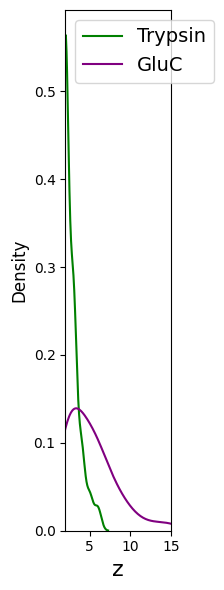

In [70]:
# Filtering data for each enzyme
trypsin_data = combined_df[combined_df['enzyme'] == e1_label]
cl3_data = combined_df[combined_df['enzyme'] == e2_label]

# Plotting the KDE for the "m/z" feature for both enzymes
plt.figure(figsize=(2, 6))
sns.kdeplot(trypsin_data['z'], label=e1_label, color='green',common_norm=True)
sns.kdeplot(cl3_data['z'], label=e2_label, color='purple',common_norm=True)

# Setting the labels and legend
plt.xlabel('z', fontsize=16)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=14)

# Control the range of x and y axis to limit whitespace if needed
plt.xlim(combined_df['z'].min(), combined_df['z'].max())
plt.ylim(0, None)  # For y-axis, setting the lower limit to 0 and upper limit to auto

# Display the plot
plt.tight_layout()
plt.show()

C:\Users\tcoop\AppData\Local\Temp\ipykernel_27528\1670999986.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trypsin_data['Enzyme'] = e1_label
C:\Users\tcoop\AppData\Local\Temp\ipykernel_27528\1670999986.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cl3_data['Enzyme'] = e2_label
C:\Users\tcoop\AppData\Local\Temp\ipykernel_27528\1670999986.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=F

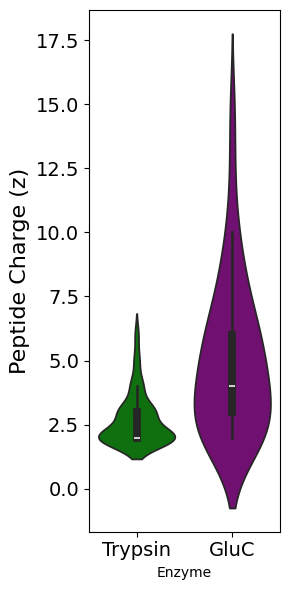

In [71]:
# Combine the two enzyme data into a single DataFrame for boxplot
trypsin_data['Enzyme'] = e1_label
cl3_data['Enzyme'] = e2_label
boxplot_data = pd.concat([trypsin_data[['z', 'Enzyme']], cl3_data[['z', 'Enzyme']]])

# Plotting the box plot for the "z" feature for both enzymes
plt.figure(figsize=(3, 6))
sns.violinplot(x='Enzyme', y='z', data=boxplot_data, palette=enzyme_color)

# Setting the labels and title
plt.ylabel('Peptide Charge (z)', fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
# Display the plot
plt.tight_layout()
plt.show()


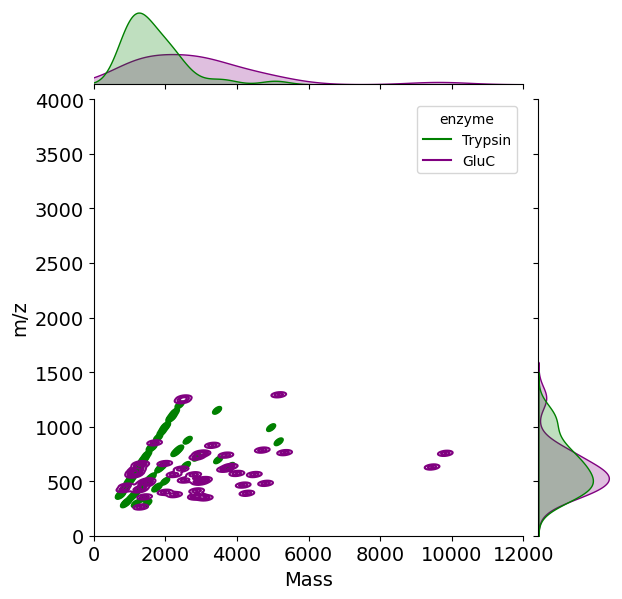

In [72]:
x="Mass"
y="m/z"
g = sns.jointplot(
    data=combined_df,
    x=x,
    y=y,
    kind="kde",
    hue='enzyme',
    palette=enzyme_color,
    fill=False,
    bw_adjust=.12,
    marginal_kws=dict(common_norm=False, fill=True)
)

# Set font size for various elements
g.set_axis_labels(x, y, fontsize=14)  # Set axis label font size
g.ax_joint.tick_params(axis='both', which='major', labelsize=14)  # Set tick label font size
# Control the range of x and y axis
g.ax_joint.set_xlim(0, 12000) 
g.ax_joint.set_ylim(0, 4000)  
# Show the plot
plt.show()


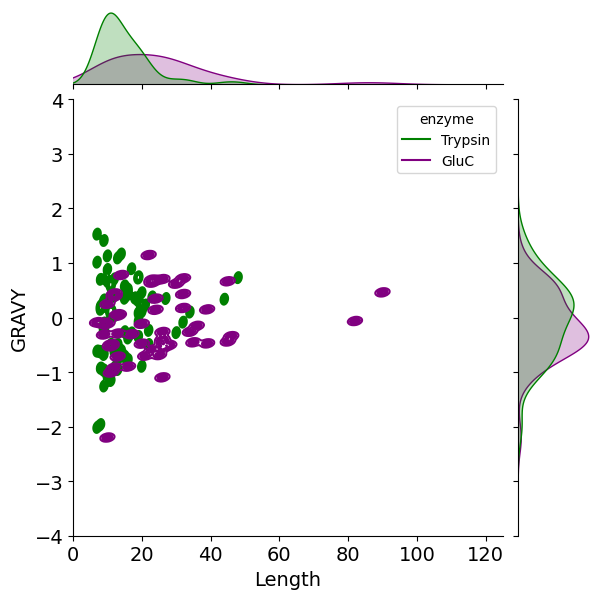

In [73]:
x="Length"
y="GRAVY"
g = sns.jointplot(
    data=combined_df,
    x=x,
    y=y,
    kind="kde",
    hue='enzyme',
    palette=enzyme_color,
    fill=False,
    bw_adjust=.12,
    marginal_kws=dict(common_norm=False, fill=True)
)

# Set font size for various elements
g.set_axis_labels(x, y, fontsize=14)  # Set axis label font size
g.ax_joint.tick_params(axis='both', which='major', labelsize=14)  # Set tick label font size
# Control the range of x and y axis
g.ax_joint.set_xlim(0, 125)  
g.ax_joint.set_ylim(-4, 4) 
# Show the plot
plt.show()

In [74]:
combined_df.to_excel("Pierre_GluC_PDK1_UBE3B.xlsx")


In [ ]:
# x="m/z"
# y="GRAVY"
# g = sns.jointplot(
#     data=peptides_df,
#     x="m/z",
#     y="GRAVY",
#     kind="kde",
# )

# # Set font size for various elements
# g.set_axis_labels("m/z", "Length", fontsize=14)  # Set axis label font size
# g.ax_joint.tick_params(axis='both', which='major', labelsize=14)  # Set tick label font size

# # Show the plot
# plt.show()


### Use this to compare two enzymes, need to merge df first. 

In [75]:
proteome_df

,UniprotID,Gene,Peptide
0,A0A0A0MT85,A0A0A0MT85,XCSFGQGTKLEIK
1,A0A0G2JMI3,HV692,MDCTWRILLLVAAATGTHAEVQLVQSGAEVKKPGATVKISCKVSGY...
2,A0A286YEV6,SCGR4,MGCCGCGSCGGCGGRCGGGCGGGCSGGCGGGCGGGCGGGCGSCTTC...
3,A0A6Q8PGS0,A0A6Q8PGS0,MKAENRCRRRPPPALNAMSLGPRRARSAPTAVAAEAPVDAAELPQR...
4,A0PJE2,DHR12,MSLYRSVVWFAKGLREYTKSGYESACKDFVPHDLEVQIPGRVFLVT...
...,...,...,...
20592,Q9Y287,ITM2B,MVKVTFNSALAQKEAKKDEPKSGEEALIIPPDAVAVDCKDPDDVVP...
20593,Q9Y2K9,STB5L,MKKFNFRKVLDGLTASSPGSGSSSGSNSGGGAGSGSVHPAGTAGVL...
20594,Q9Y592,CEP83,MVVSTFTDMDTFPNNFPPGGDSGLTGSQSEFQKMLIDERLRCEHHK...
20595,Q9Y6S9,RPKL1,MSLVACECLPSPGLEPEPCSRARSQAHVYLEQIRNRVALGVPDMTK...


In [76]:
# Example of mapping step if needed:
protein_sequence_map = proteome_df.set_index('Gene')['Peptide'].to_dict()  # Adjust column names as necessary
combined_df['Protein_Sequence'] = combined_df['gene'].map(protein_sequence_map)


In [77]:
combined_df.columns

Index(['gene', 'peptide', 'Length', 'aa_comp', 'neutral_z', 'z', 'Mass',
       'GRAVY', 'm/z', 'enzyme', 'Protein_Sequence'],
      dtype='object')

In [78]:
def Pep2Pro(protein, peptides):
    protein = re.sub(r'[^A-Z]', '', protein)
    mask = np.zeros(len(protein), dtype=np.int8)
    for peptide in peptides:
        indices = [m.start() for m in re.finditer('(?={})'.format(re.sub(r'[^A-Z]', '', peptide)), protein)]
        for i in indices:
            mask[i:i + len(peptide)] = 1
    return mask.sum() / mask.size


In [79]:
# Filter data for each enzyme
df_trypsin = combined_df[combined_df['enzyme'] == e1_label]
df_CL3 = combined_df[combined_df['enzyme'] == e2_label]

# Define a function to calculate coverage for each group
def calculate_coverage(group):
    protein_sequence = group['Protein_Sequence'].iloc[0]
    peptides = group['peptide'].tolist()
    return Pep2Pro(protein_sequence, peptides)

# Group by 'gene' and calculate coverage
coverage_trypsin = df_trypsin.groupby('gene').apply(calculate_coverage)
coverage_CL3 = df_CL3.groupby('gene').apply(calculate_coverage)


C:\Users\tcoop\AppData\Local\Temp\ipykernel_27528\2965090438.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage_trypsin = df_trypsin.groupby('gene').apply(calculate_coverage)
C:\Users\tcoop\AppData\Local\Temp\ipykernel_27528\2965090438.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage_CL3 = df_CL3.groupby('gene').apply(calculate_coverage)


In [80]:
print(df_trypsin.head())
print("Number of rows in df_trypsin:", len(df_trypsin))


   gene           peptide  Length  \
0  CDK1       IGEGTYGVVYK      11   
1  CDK1         TTGQVVAMK       9   
2  CDK1    LESEEEGVPSTAIR      14   
3  CDK1  HPNIVSLQDVLMQDSR      16   
4  CDK1     LYLIFEFLSMDLK      13   

                                             aa_comp  neutral_z  z  \
0  {'G': 3, 'V': 2, 'T': 1, 'E': 1, 'I': 1, 'Y': ...          0  2   
1  {'V': 2, 'G': 1, 'T': 2, 'K': 1, 'Q': 1, 'A': ...          1  2   
2  {'G': 1, 'V': 1, 'T': 1, 'E': 4, 'I': 1, 'P': ...         -3  2   
3  {'Q': 2, 'V': 2, 'I': 1, 'M': 1, 'D': 2, 'H': ...         -1  3   
4  {'E': 1, 'I': 1, 'M': 1, 'Y': 1, 'K': 1, 'D': ...         -1  2   

          Mass     GRAVY         m/z   enzyme  \
0  1165.613144  0.090909  582.806572  Trypsin   
1   916.468805  0.322222  458.234402  Trypsin   
2  1493.795042 -0.607143  746.897521  Trypsin   
3  1834.888347 -0.375000  611.629449  Trypsin   
4  1611.873465  1.092308  805.936732  Trypsin   

                                    Protein_Sequence  
0  MED

In [81]:
# Correct conversion of coverage Series to DataFrames and renaming the coverage column
coverage_trypsin_df = coverage_trypsin.reset_index().rename(columns={0: e1_label})
coverage_CL3_df = coverage_CL3.reset_index().rename(columns={0: e2_label})

# Merge the coverage data
coverage_merged = pd.merge(coverage_trypsin_df, coverage_CL3_df, on='gene', how='outer').fillna(0)
coverage_merged[e1_label] = coverage_merged[e1_label] * 100
coverage_merged[e2_label] = coverage_merged[e2_label] * 100



In [82]:
coverage_merged.rename(columns={'gene': 'Gene'}, inplace=True)
coverage_merged

,Gene,Trypsin,GluC
0,CDK1,82.491582,90.572391
1,UBE3B,81.273408,91.760300


C:\Users\tcoop\AppData\Local\Temp\ipykernel_27528\1815276199.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Enzyme', y='Coverage', data=coverage_long, palette=palette, fill=None,inner='quart')


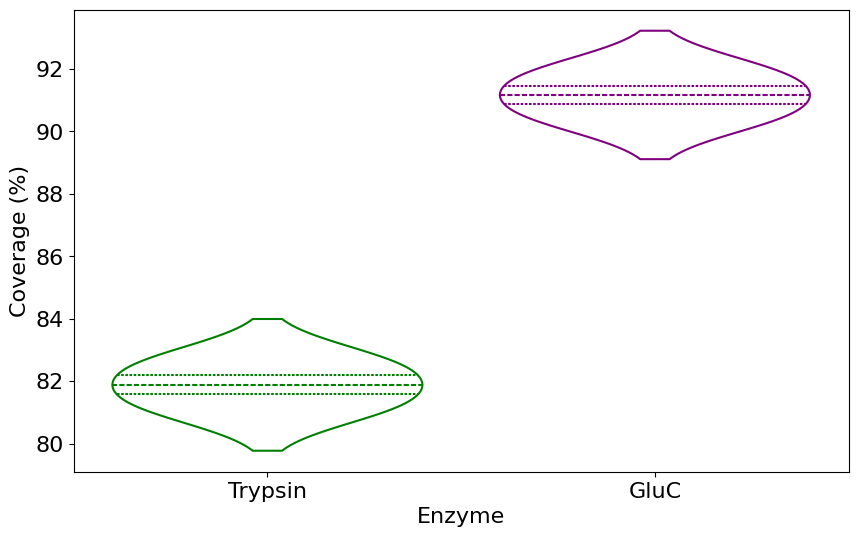

In [83]:

coverage_long = pd.melt(coverage_merged, id_vars=['Gene'], value_vars=[e1_label, e2_label], var_name='Enzyme', value_name='Coverage')
palette = {e1_label: 'green', e2_label: 'purple'}
plt.figure(figsize=(10, 6))
sns.violinplot(x='Enzyme', y='Coverage', data=coverage_long, palette=palette, fill=None,inner='quart')
plt.ylabel('Coverage (%)',fontsize=16)
plt.xlabel('Enzyme',fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Show the plot
plt.show()


C:\Users\tcoop\AppData\Local\Temp\ipykernel_27528\469241799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Enzyme', y='Coverage', data=coverage_long, palette=palette, width=0.5)


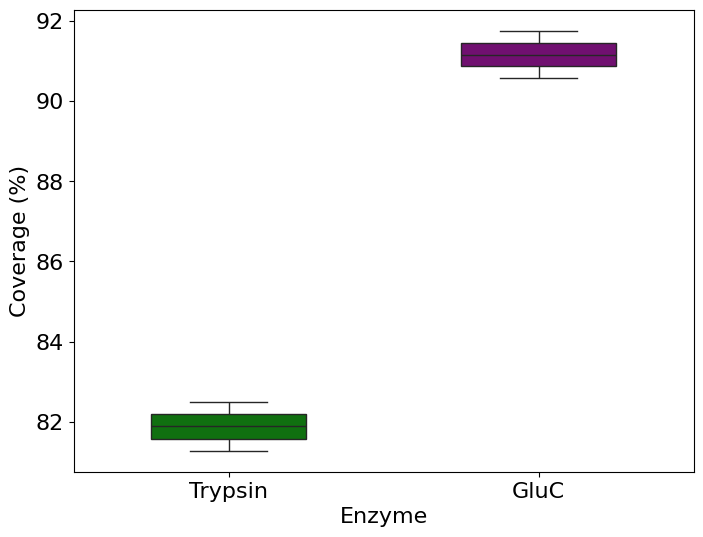

In [84]:

palette = {e1_label: 'green', e2_label: 'purple'}

plt.figure(figsize=(8, 6))
sns.boxplot(x='Enzyme', y='Coverage', data=coverage_long, palette=palette, width=0.5)

plt.ylabel('Coverage (%)', fontsize=16)
plt.xlabel('Enzyme', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.show()


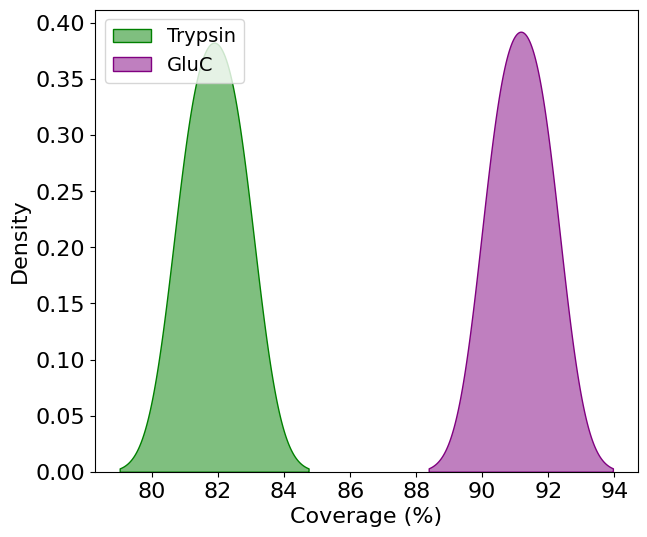

In [85]:
coverage_long = pd.melt(coverage_merged, id_vars=['Gene'], value_vars=[e1_label, e2_label], var_name='Enzyme', value_name='Coverage')
palette = {e1_label: 'green', e2_label: 'purple'}

plt.figure(figsize=(7, 6))

# Plot KDE for Trypsin
sns.kdeplot(data=coverage_long[coverage_long['Enzyme'] == e1_label]['Coverage'], 
            color=palette[e1_label], label=e1_label, fill=True, alpha=0.5)

# Plot KDE for CL3
sns.kdeplot(data=coverage_long[coverage_long['Enzyme'] == e2_label]['Coverage'], 
            color=palette[e2_label], label=e2_label, fill=True, alpha=0.5)

plt.ylabel('Density', fontsize=16)
plt.xlabel('Coverage (%)', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=14,loc="upper left")

# Show the plot
plt.show()

In [86]:
# Example adjustment: Simplify to handle a single cleavage per peptide
def capture_flanking_sequences(protein_sequence, peptide_sequence, flank_length):
    peptide_start = protein_sequence.find(peptide_sequence)
    if peptide_start == -1:
        return {'n_cut': 'Not found', 'c_cut': 'Not found'}
    
    # Example rule: cleavage occurs at the start of the peptide
    n_cut_start = max(0, peptide_start - flank_length)
    c_cut_end = min(len(protein_sequence), peptide_start + len(peptide_sequence) + flank_length)
    
    n_cut = protein_sequence[n_cut_start:peptide_start]
    c_cut = protein_sequence[peptide_start + len(peptide_sequence):c_cut_end]
    
    return {'n_cut': n_cut, 'c_cut': c_cut}



# Apply the adjusted function to each row in df_trypsin
df_trypsin['flanking_sequences'] = df_trypsin.apply(
    lambda row: capture_flanking_sequences(row['Protein_Sequence'], row['peptide'], 5), axis=1
)

# Apply the adjusted function to each row in df_trypsin
df_CL3['flanking_sequences'] = df_CL3.apply(
    lambda row: capture_flanking_sequences(row['Protein_Sequence'], row['peptide'], 5), axis=1
)



C:\Users\tcoop\AppData\Local\Temp\ipykernel_27528\2777988211.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trypsin['flanking_sequences'] = df_trypsin.apply(
C:\Users\tcoop\AppData\Local\Temp\ipykernel_27528\2777988211.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_CL3['flanking_sequences'] = df_CL3.apply(


In [87]:
print(df_trypsin[['peptide', 'flanking_sequences']].head())


            peptide                    flanking_sequences
0       IGEGTYGVVYK  {'n_cut': 'TKIEK', 'c_cut': 'GRHKT'}
1         TTGQVVAMK  {'n_cut': 'KGRHK', 'c_cut': 'KIRLE'}
2    LESEEEGVPSTAIR  {'n_cut': 'MKKIR', 'c_cut': 'EISLL'}
3  HPNIVSLQDVLMQDSR  {'n_cut': 'LKELR', 'c_cut': 'LYLIF'}
4     LYLIFEFLSMDLK  {'n_cut': 'MQDSR', 'c_cut': 'KYLDS'}


In [88]:
import pandas as pd

# Define positions relative to the cleavage site
positions = ['P5', 'P4', 'P3', 'P2', 'P1', 'P1\'', 'P2\'', 'P3\'', 'P4\'', 'P5\'']

# Initialize a DataFrame to hold the counts for each amino acid at each position
tryp_aa_counts = pd.DataFrame(columns=['AminoAcid'] + positions).set_index('AminoAcid')
cl3_aa_counts = pd.DataFrame(columns=['AminoAcid'] + positions).set_index('AminoAcid')
# Populate the DataFrame with zeros for each amino acid at each position
amino_acids = 'ACDEFGHIKLMNPQRSTVWYUX'  # Standard amino acids
for aa in amino_acids:
    tryp_aa_counts.loc[aa] = [0] * len(positions)
    cl3_aa_counts.loc[aa] = [0] * len(positions)
cl3_aa_counts


,P5,P4,P3,P2,P1,P1',P2',P3',P4',P5'
AminoAcid,,,,,,,,,,
A,0,0,0,0,0,0,0,0,0,0
C,0,0,0,0,0,0,0,0,0,0
D,0,0,0,0,0,0,0,0,0,0
E,0,0,0,0,0,0,0,0,0,0
F,0,0,0,0,0,0,0,0,0,0
G,0,0,0,0,0,0,0,0,0,0
H,0,0,0,0,0,0,0,0,0,0
I,0,0,0,0,0,0,0,0,0,0
K,0,0,0,0,0,0,0,0,0,0


In [89]:
def update_aa_counts_from_flanking(row, aa_counts):
    # Extract the flanking sequences
    n_cut = row['flanking_sequences']['n_cut']
    c_cut = row['flanking_sequences']['c_cut']

    # Update counts for N-terminal side
    for i, aa in enumerate(n_cut[::-1], 1):
        if i <= len(positions) // 2:  # Assuming positions are symmetric around cleavage
            aa_counts.loc[aa, f'P{i}'] += 1

    # Update counts for C-terminal side
    for i, aa in enumerate(c_cut, 1):
        if i <= len(positions) // 2:  # Assuming positions are symmetric around cleavage
            aa_counts.loc[aa, f"P{i}'"] += 1

# Apply the function to each row in the DataFrame
df_trypsin.apply(lambda row: update_aa_counts_from_flanking(row, tryp_aa_counts), axis=1)
df_CL3.apply(lambda row: update_aa_counts_from_flanking(row, cl3_aa_counts), axis=1)



# from multiprocessing import Pool


# def process_chunk(chunk):
#     # Initialize a local count DataFrame for this chunk
#     local_counts = pd.DataFrame(columns=positions, index=list('ACDEFGHIKLMNPQRSTVWYUX')).fillna(0)
    
#     for _, row in chunk.iterrows():
#         n_cut = row['flanking_sequences']['n_cut']
#         c_cut = row['flanking_sequences']['c_cut']
        
#         # Update counts for N-terminal side
#         for i, aa in enumerate(n_cut[::-1], 1):
#             if i <= len(positions) // 2:
#                 local_counts.loc[aa, f'P{i}'] += 1
        
#         # Update counts for C-terminal side
#         for i, aa in enumerate(c_cut, 1):
#             if i <= len(positions) // 2:
#                 local_counts.loc[aa, f"P{i}'"] += 1
    
#     return local_counts

# def parallelize_dataframe_processing(df, func, num_partitions, num_cores):
#     df_split = np.array_split(df, num_partitions)
#     pool = Pool(num_cores)
#     result_list = pool.map(func, df_split)
#     pool.close()
#     pool.join()
#     # Combine the results from all chunks
#     combined_result = pd.concat(result_list, axis=0).groupby(level=0).sum()
#     return combined_result

# # Example of how to use this setup
# num_partitions = 10  # Adjust based on your dataset size and available memory
# num_cores = 4  # Adjust based on your machine's capabilities

# # Replace df_trypsin with the actual DataFrame you're working with
# tryp_aa_counts = parallelize_dataframe_processing(df_trypsin, process_chunk, num_partitions, num_cores)
# cl3_aa_counts = parallelize_dataframe_processing(df_CL3, process_chunk, num_partitions, num_cores)

# # tryp_aa_counts and cl3_aa_counts now hold the aggregated amino acid counts for each position



75     None
76     None
77     None
78     None
79     None
80     None
81     None
82     None
83     None
84     None
85     None
86     None
87     None
88     None
89     None
90     None
91     None
92     None
93     None
94     None
95     None
96     None
97     None
98     None
99     None
100    None
101    None
102    None
103    None
104    None
105    None
106    None
107    None
108    None
109    None
110    None
111    None
112    None
113    None
114    None
115    None
116    None
117    None
118    None
119    None
120    None
121    None
122    None
123    None
124    None
dtype: object

In [90]:
t_aa_probabilities = tryp_aa_counts.div(tryp_aa_counts.sum(axis=0), axis=1)
t_aa_probabilities.head(23)
t_aa_df=t_aa_probabilities.T
t_aa_df.reset_index(drop=True, inplace=True)
t_aa_df.columns.name = None
t_aa_df.index.name = 'pos'
t_aa_df


,A,C,D,E,F,G,H,I,K,L,...,P,Q,R,S,T,V,W,Y,U,X
pos,,,,,,,,,,,,,,,,,,,,,
0,0.040541,0.027027,0.067568,0.094595,0.040541,0.013514,0.067568,0.094595,0.067568,0.081081,...,0.054054,0.027027,0.054054,0.067568,0.067568,0.081081,0.000000,0.013514,0.0,0.0
1,0.027027,0.027027,0.108108,0.108108,0.027027,0.121622,0.000000,0.067568,0.054054,0.121622,...,0.054054,0.040541,0.027027,0.081081,0.040541,0.013514,0.013514,0.000000,0.0,0.0
2,0.013514,0.027027,0.040541,0.054054,0.040541,0.067568,0.013514,0.081081,0.040541,0.202703,...,0.027027,0.067568,0.108108,0.108108,0.027027,0.040541,0.027027,0.000000,0.0,0.0
3,0.040541,0.027027,0.000000,0.067568,0.094595,0.067568,0.040541,0.121622,0.121622,0.067568,...,0.040541,0.027027,0.040541,0.108108,0.040541,0.054054,0.013514,0.013514,0.0,0.0
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.513514,0.000000,...,0.000000,0.000000,0.486486,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
5,0.053333,0.013333,0.040000,0.026667,0.000000,0.093333,0.013333,0.066667,0.120000,0.133333,...,0.000000,0.053333,0.080000,0.066667,0.026667,0.066667,0.000000,0.013333,0.0,0.0
6,0.013333,0.026667,0.026667,0.026667,0.120000,0.000000,0.026667,0.133333,0.000000,0.200000,...,0.040000,0.013333,0.040000,0.053333,0.066667,0.066667,0.040000,0.080000,0.0,0.0
7,0.040541,0.000000,0.040541,0.054054,0.081081,0.027027,0.013514,0.108108,0.027027,0.189189,...,0.027027,0.013514,0.081081,0.081081,0.108108,0.040541,0.013514,0.027027,0.0,0.0
8,0.027027,0.027027,0.040541,0.067568,0.040541,0.054054,0.027027,0.081081,0.094595,0.148649,...,0.054054,0.027027,0.054054,0.054054,0.054054,0.067568,0.027027,0.040541,0.0,0.0


In [91]:
c_aa_probabilities = cl3_aa_counts.div(cl3_aa_counts.sum(axis=0), axis=1)
c_aa_probabilities.head(23)
c_aa_df=c_aa_probabilities.T
c_aa_df.reset_index(drop=True, inplace=True)
c_aa_df.columns.name = None
c_aa_df.index.name = 'pos'
c_aa_df

,A,C,D,E,F,G,H,I,K,L,...,P,Q,R,S,T,V,W,Y,U,X
pos,,,,,,,,,,,,,,,,,,,,,
0,0.040816,0.020408,0.040816,0.122449,0.061224,0.020408,0.020408,0.061224,0.040816,0.142857,...,0.020408,0.040816,0.040816,0.061224,0.040816,0.081633,0.020408,0.061224,0.0,0.0
1,0.040816,0.000000,0.081633,0.081633,0.061224,0.102041,0.000000,0.081633,0.061224,0.122449,...,0.020408,0.020408,0.061224,0.081633,0.040816,0.102041,0.000000,0.020408,0.0,0.0
2,0.000000,0.040816,0.081633,0.102041,0.040816,0.040816,0.000000,0.061224,0.081633,0.183673,...,0.020408,0.000000,0.040816,0.081633,0.122449,0.061224,0.000000,0.040816,0.0,0.0
3,0.040816,0.020408,0.102041,0.122449,0.061224,0.040816,0.040816,0.000000,0.020408,0.081633,...,0.122449,0.040816,0.081633,0.040816,0.000000,0.061224,0.000000,0.061224,0.0,0.0
4,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
5,0.020408,0.020408,0.081633,0.061224,0.040816,0.020408,0.000000,0.102041,0.040816,0.142857,...,0.020408,0.000000,0.081633,0.122449,0.000000,0.122449,0.020408,0.000000,0.0,0.0
6,0.061224,0.000000,0.102041,0.081633,0.000000,0.102041,0.020408,0.061224,0.020408,0.224490,...,0.020408,0.061224,0.020408,0.061224,0.020408,0.040816,0.020408,0.040816,0.0,0.0
7,0.000000,0.020833,0.041667,0.125000,0.000000,0.020833,0.020833,0.041667,0.083333,0.125000,...,0.083333,0.041667,0.104167,0.041667,0.083333,0.041667,0.020833,0.041667,0.0,0.0
8,0.000000,0.000000,0.125000,0.125000,0.041667,0.104167,0.020833,0.000000,0.041667,0.166667,...,0.062500,0.020833,0.083333,0.020833,0.020833,0.083333,0.000000,0.020833,0.0,0.0


In [58]:
logomaker.list_font_names()

['Arial',
 'Bahnschrift',
 'Calibri',
 'Cambria',
 'Candara',
 'Comic Sans MS',
 'Consolas',
 'Constantia',
 'Corbel',
 'Courier New',
 'DejaVu Sans',
 'DejaVu Sans Display',
 'DejaVu Sans Mono',
 'DejaVu Serif',
 'DejaVu Serif Display',
 'Ebrima',
 'Franklin Gothic Medium',
 'Gabriola',
 'Gadugi',
 'Georgia',
 'HoloLens MDL2 Assets',
 'Impact',
 'Ink Free',
 'Javanese Text',
 'Leelawadee UI',
 'Lucida Console',
 'Lucida Sans Unicode',
 'MS Gothic',
 'MV Boli',
 'Malgun Gothic',
 'Microsoft Himalaya',
 'Microsoft JhengHei',
 'Microsoft New Tai Lue',
 'Microsoft PhagsPa',
 'Microsoft Sans Serif',
 'Microsoft Tai Le',
 'Microsoft YaHei',
 'Microsoft Yi Baiti',
 'MingLiU-ExtB',
 'Mongolian Baiti',
 'Myanmar Text',
 'Nirmala UI',
 'Orbitron',
 'Palatino Linotype',
 'STIXGeneral',
 'STIXNonUnicode',
 'STIXSizeFiveSym',
 'STIXSizeFourSym',
 'STIXSizeOneSym',
 'STIXSizeThreeSym',
 'STIXSizeTwoSym',
 'Segoe MDL2 Assets',
 'Segoe Print',
 'Segoe Script',
 'Segoe UI',
 'Segoe UI Emoji',
 'Segoe 

Text(0, 0.5, 'probability')

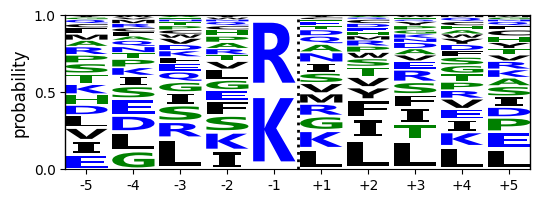

In [92]:
# TRYPSIN LOGO
ss_logo = logomaker.Logo(t_aa_df,
                         width=.9,
                         vpad=.2,
                         stack_order='small_on_top',
                         color_scheme='hydrophobicity',
                         font_name="Ebrima",
                         fade_probabilities=False,
                          center_values=False,
                         alpha=1,figsize=[6,2])
# style using Logo methods
ss_logo.style_spines(spines=['left', 'right'], visible=True)
# ss_logo.fade_glyphs_in_probability_logo(v_alpha0=0.6,v_alpha1=1)
# style using Axes methods
ss_logo.ax.set_xticks(range(len(t_aa_df)))
ss_logo.ax.set_xticklabels('%+d'%x for x in [ -5, -4, -3, -2, -1, 1, 2, 3, 4,5])
ss_logo.ax.set_yticks([0, .5, 1])
ss_logo.ax.axvline(4.5, color='k', linewidth=2, linestyle=':')
ss_logo.ax.set_ylabel('probability',fontsize=12)



Text(0, 0.5, 'probability')

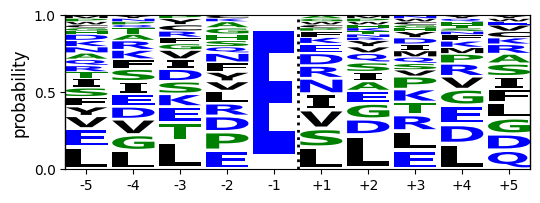

In [93]:
# CL3 LOGO
ss_logo = logomaker.Logo(c_aa_df,
                         width=.9,
                         vpad=.2,
                         stack_order='small_on_top',
                         color_scheme='hydrophobicity',
                         font_name="Ebrima",
                         fade_probabilities=False,
                          center_values=False,
                         alpha=1,figsize=[6,2])
# style using Logo methods
ss_logo.style_spines(spines=['left', 'right'], visible=True)
# ss_logo.fade_glyphs_in_probability_logo(v_alpha0=0.6,v_alpha1=1)
# style using Axes methods
ss_logo.ax.set_xticks(range(len(c_aa_df)))
ss_logo.ax.set_xticklabels('%+d'%x for x in [ -5, -4, -3, -2, -1, 1, 2, 3, 4,5])
ss_logo.ax.set_yticks([0, .5, 1])
ss_logo.ax.axvline(4.5, color='k', linewidth=2, linestyle=':')
ss_logo.ax.set_ylabel('probability',fontsize=12)
